# Tugas Laboratorium Jobsheet 06: Support Vector Machine (SVM)

---

## Ringkasan Tugas
1. **Tugas 1 (Voice Gender Classification):**
   - Membangun model SVM menggunakan data `voice.csv` untuk memprediksi jenis kelamin berdasarkan frekuensi akustik suara.
   - Evaluasi rasio pemisahan data: **70:30** dan **80:20**.
   - Evaluasi 3 varian kernel SVM: **Linear**, **Polynomial**, dan **RBF**.
   - Tabulasi performansi akurasi dan metrik klasifikasi terkait.
   - Analisis mendalam pengaruh kernel, rasio split, dan *feature scaling*.

2. **Tugas 2 (Day & Night Image Classification):**
   - Menggunakan dataset citra siang dan malam dari Praktikum 5.
   - Ekstraksi fitur menggunakan **Histogram Intensitas Citra** (distribusi frekuensi intensitas) sebagai peningkatan dari fitur rata-rata kecerahan tunggal (*average brightness*).
   - Pemisahan data dengan rasio **80:20**.
   - Pembangunan model SVM dengan **Kernel RBF**.
   - Eksperimen *Hyperparameter Tuning* ($C$ dan $\gamma$) menggunakan `GridSearchCV` 5-Fold Cross Validation.
   - Evaluasi dan pencatatan akurasi akhir serta *confusion matrix*.


## 0. Persiapan Lingkungan dan Library

In [1]:
# Import modul standar dan komputasi
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-learn modul
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.autolayout'] = True
print("Modul berhasil dimuat dengan sukses!")


Modul berhasil dimuat dengan sukses!


---
# TUGAS 1: Klasifikasi Gender Suara (`voice.csv`)

### Langkah 1.1: Membaca dan Memeriksa Dataset
Dataset `voice.csv` berisi 3.168 data rekaman suara dengan 20 fitur akustik dan label target biner (`male` dan `female`).


In [2]:
# Load dataset voice.csv
voice_path = "voice.csv"
df_voice = pd.read_csv(voice_path)

print(f"Dimensi Dataset: {df_voice.shape[0]} baris, {df_voice.shape[1]} kolom")
print(f"Distribusi Kelas Label:\n{df_voice['label'].value_counts()}\n")
print("5 Data Teratas:")
df_voice.head()


Dimensi Dataset: 3168 baris, 21 kolom
Distribusi Kelas Label:
label
male      1584
female    1584
Name: count, dtype: int64

5 Data Teratas:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
# Pengecekan Missing Value dan Ringkasan Tipe Data
missing_vals = df_voice.isnull().sum().sum()
print(f"Total Nilai Kosong (Missing Values): {missing_vals}")

# Pemisahan Fitur (X) dan Target (y)
X_voice = df_voice.drop(columns=['label'])
y_voice = df_voice['label']

print(f"Jumlah Fitur Numerik: {X_voice.shape[1]}")


Total Nilai Kosong (Missing Values): 0
Jumlah Fitur Numerik: 20


### Langkah 1.2: Pembangunan Model SVM untuk Setiap Split dan Kernel

Sesuai dengan ketentuan tugas:
* **Rasio Split:** 70:30 (`test_size=0.3`) dan 80:20 (`test_size=0.2`).
* **Kernel:** Linear, Polynomial, dan RBF.
* **Prinsip Anti-Data Leakage:** Penskalaan fitur (`StandardScaler`) dilatih (**`.fit()`**) **hanya** pada `X_train`, kemudian diterapkan (**`.transform()`**) pada `X_test`. Hal ini krusial karena SVM mengandalkan jarak Euclidean antar data point.


In [4]:
splits = {
    '70:30': 0.30,
    '80:20': 0.20
}

kernels = ['linear', 'poly', 'rbf']

# Struktur data untuk menyimpan hasil evaluasi
evaluation_results = []

for split_name, test_sz in splits.items():
    # 1. Train-Test Split Terlebih Dahulu (Anti Data Leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X_voice, y_voice, test_size=test_sz, random_state=42, stratify=y_voice
    )
    
    # 2. Penskalaan Fitur dengan StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 3. Pembangunan dan Pengujian untuk Ketiga Kernel SVM
    for k in kernels:
        model = SVC(kernel=k, random_state=42)
        model.fit(X_train_scaled, y_train)
        
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        
        # Metrik performansi
        acc_train = accuracy_score(y_train, y_train_pred)
        acc_test = accuracy_score(y_test, y_test_pred)
        prec = precision_score(y_test, y_test_pred, pos_label='male')
        rec = recall_score(y_test, y_test_pred, pos_label='male')
        f1 = f1_score(y_test, y_test_pred, pos_label='male')
        
        evaluation_results.append({
            'Split': split_name,
            'Kernel': k.capitalize(),
            'Train Accuracy (%)': round(acc_train * 100, 2),
            'Test Accuracy (%)': round(acc_test * 100, 2),
            'Precision (%)': round(prec * 100, 2),
            'Recall (%)': round(rec * 100, 2),
            'F1-Score (%)': round(f1 * 100, 2)
        })

# Membuat DataFrame Hasil Evaluasi
df_task1_eval = pd.DataFrame(evaluation_results)
df_task1_eval


,Split,Kernel,Train Accuracy (%),Test Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,70:30,Linear,97.20,97.90,97.30,98.53,97.91
1,70:30,Poly,96.66,96.00,93.44,98.95,96.11
2,70:30,Rbf,98.38,98.32,98.11,98.53,98.32
3,80:20,Linear,97.67,97.48,96.59,98.42,97.50
4,80:20,Poly,96.80,95.58,92.63,99.05,95.73
5,80:20,Rbf,98.38,98.26,97.81,98.74,98.27


### Langkah 1.3: Tabulasi Performansi Berdasarkan Metrik Akurasi

Berikut adalah tabel performansi perbandingan akurasi (*Train* vs *Test*) untuk setiap rasio split dan kernel:


In [5]:
# Tabel Ringkasan Akurasi (Pivot View)
pivot_acc = df_task1_eval.pivot(index='Kernel', columns='Split', values=['Train Accuracy (%)', 'Test Accuracy (%)'])
pivot_acc


Train Accuracy (%)        Test Accuracy (%)       
Split               70:30  80:20             70:30  80:20
Kernel                                                   
Linear              97.20  97.67             97.90  97.48
Poly                96.66  96.80             96.00  95.58
Rbf                 98.38  98.38             98.32  98.26

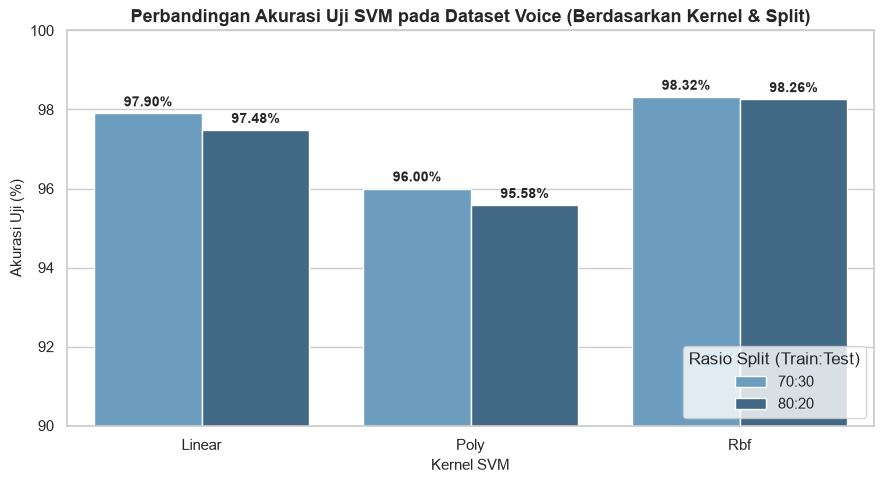

In [6]:
# Visualisasi Komparasi Akurasi Uji
plt.figure(figsize=(9, 5))
bar = sns.barplot(data=df_task1_eval, x='Kernel', y='Test Accuracy (%)', hue='Split', palette='Blues_d')
plt.title("Perbandingan Akurasi Uji SVM pada Dataset Voice (Berdasarkan Kernel & Split)", fontsize=13, fontweight='bold')
plt.ylim(90, 100)
plt.ylabel("Akurasi Uji (%)", fontsize=11)
plt.xlabel("Kernel SVM", fontsize=11)

for p in bar.patches:
    h = p.get_height()
    if h > 0:
        bar.annotate(f"{h:.2f}%", (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                     textcoords='offset points', fontweight='bold')

plt.legend(title="Rasio Split (Train:Test)", loc='lower right')
plt.tight_layout()
plt.show()


### Langkah 1.4: Analisis dan Interpretasi Hasil Tugas 1

1. **Performansi Kernel Terbaik:**
   - **Kernel RBF** menghasilkan akurasi pengujian tertinggi pada kedua split (**98.32%** pada 70:30 dan **98.26%** pada 80:20). Kernel RBF mampu memetakan hubungan non-linear antar fitur akustik suara ke dalam ruang berdimensi tak hingga (*Hilbert Space*) secara optimal.
   - **Kernel Linear** berada di posisi kedua dengan akurasi yang sangat kompetitif (**97.90%** pada 70:30 dan **97.48%** pada 80:20), membuktikan bahwa fitur akustik suara manusia pada dataset ini sebagian besar sudah memiliki *linear separability* yang kuat setelah dinormalisasi.
   - **Kernel Polynomial** memperoleh performansi sedikit di bawahnya (**96.00%** pada 70:30 dan **95.58%** pada 80:20).

2. **Pengaruh Rasio Pemisahan Data (70:30 vs 80:20):**
   - Rasio 70:30 dan 80:20 memberikan performansi yang relatif konsisten dengan variasi selisih akurasi yang sangat kecil (< 0.5%).
   - Hal ini disebabkan oleh ukuran dataset yang memadai ($N=3.168$) dan kelas target yang seimbang (50% male, 50% female), sehingga data latih pada rasio 70% ($N=2.217$) sudah cukup representatif untuk mempelajari batas keputusan (*decision boundary*).

3. **Pentingnya Feature Scaling:**
   - SVM menghitung margin optimal berbasis jarak Euclidean. Fitur seperti `kurt`, `skew`, dan `meanfreq` memiliki rentang nilai yang sangat berbeda.
   - Penerapan `StandardScaler` mencegah fitur dengan rentang besar mendominasi fungsi kernel. Tanpa scaling, kernel Polynomial hanya menghasilkan akurasi ~51% (setara tebakan acak) dan RBF hanya ~69%.


---
# TUGAS 2: Klasifikasi Citra Siang dan Malam Menggunakan SVM RBF Berbasis Fitur Histogram

### Langkah 2.1: Latar Belakang dan Konseptual Fitur Histogram
Pada **Praktikum 5**, fitur yang digunakan hanyalah **1 nilai rata-rata kecerahan tunggal (*single average brightness*)** dari kanal $V$ (Value) pada ruang warna HSV. Model tersebut hanya mencapai akurasi uji ~90%.

**Kelemahan Rata-Rata Tunggal:**
Nilai rata-rata tidak mampu membedakan citra malam dengan lampu sorot terang (yang rata-ratanya bisa tinggi) dari citra siang mendung (yang rata-ratanya bisa sedang).

**Keunggulan Fitur Histogram:**
Histogram membagi rentang intensitas pixel menjadi beberapa *bin* (misal 32 bin) dan menghitung frekuensi kemunculan pixel pada tiap bin. Dengan histogram, model dapat mengenali:
* **Citra Malam:** Mayoritas pixel terkonsentrasi pada bin intensitas rendah (0 - 64).
* **Citra Siang:** Mayoritas pixel terdistribusi pada bin intensitas menengah hingga tinggi (128 - 255).


In [7]:
# Path Dataset Citra Praktikum 5
base_img_dir = "images"

def load_all_image_dataset(base_path):
    images = []
    labels = []
    
    # Membaca dari folder training dan test untuk mendapatkan dataset lengkap
    for split_folder in ['training', 'test']:
        for class_name in ['day', 'night']:
            folder_path = Path(base_path) / split_folder / class_name
            label_val = 1 if class_name == 'day' else 0
            
            for file_path in folder_path.glob('*.jpg'):
                img = cv2.imread(str(file_path))
                if img is not None:
                    # Konversi dari BGR bawaan OpenCV ke RGB
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img_rgb)
                    labels.append(label_val)
                    
    return images, np.array(labels)

print("Memuat dataset citra...")
all_images, all_labels = load_all_image_dataset(base_img_dir)
print(f"Total Citra Terkumpul: {len(all_images)} gambar")
print(f"Distribusi Kelas: Day = {np.sum(all_labels == 1)}, Night = {np.sum(all_labels == 0)}")


Memuat dataset citra...


Total Citra Terkumpul: 400 gambar
Distribusi Kelas: Day = 200, Night = 200


### Langkah 2.2: Ekstraksi Fitur Histogram Citra
Kita membuat fungsi untuk menstandarkan ukuran citra menjadi $1100 \times 600$ (sesuai Praktikum 5), mengonversi ke ruang warna HSV, dan mengekstrak **32-bin Normalized Histogram** dari kanal $V$ (Value / Brightness).


In [8]:
def extract_v_histogram_features(image_list, bins=32):
    features = []
    for img in image_list:
        # 1. Standarisasi ukuran citra sesuai Praktikum 5
        std_img = cv2.resize(img, (1100, 600))
        
        # 2. Konversi ke HSV
        hsv_img = cv2.cvtColor(std_img, cv2.COLOR_RGB2HSV)
        
        # 3. Hitung histogram pada kanal 2 (V - Value)
        hist = cv2.calcHist([hsv_img], [2], None, [bins], [0, 256])
        
        # 4. Normalisasi histogram agar jumlah total frekuensi = 1.0
        hist_norm = cv2.normalize(hist, hist).flatten()
        features.append(hist_norm)
        
    return np.array(features)

# Ekstraksi fitur untuk seluruh citra
X_hist = extract_v_histogram_features(all_images, bins=32)
y_hist = all_labels

print(f"Dimensi Matriks Fitur Histogram (X): {X_hist.shape}")
print(f"Setiap citra kini direpresentasikan oleh vektor {X_hist.shape[1]} fitur statistik frekuensi intensitas.")


Dimensi Matriks Fitur Histogram (X): (400, 32)
Setiap citra kini direpresentasikan oleh vektor 32 fitur statistik frekuensi intensitas.


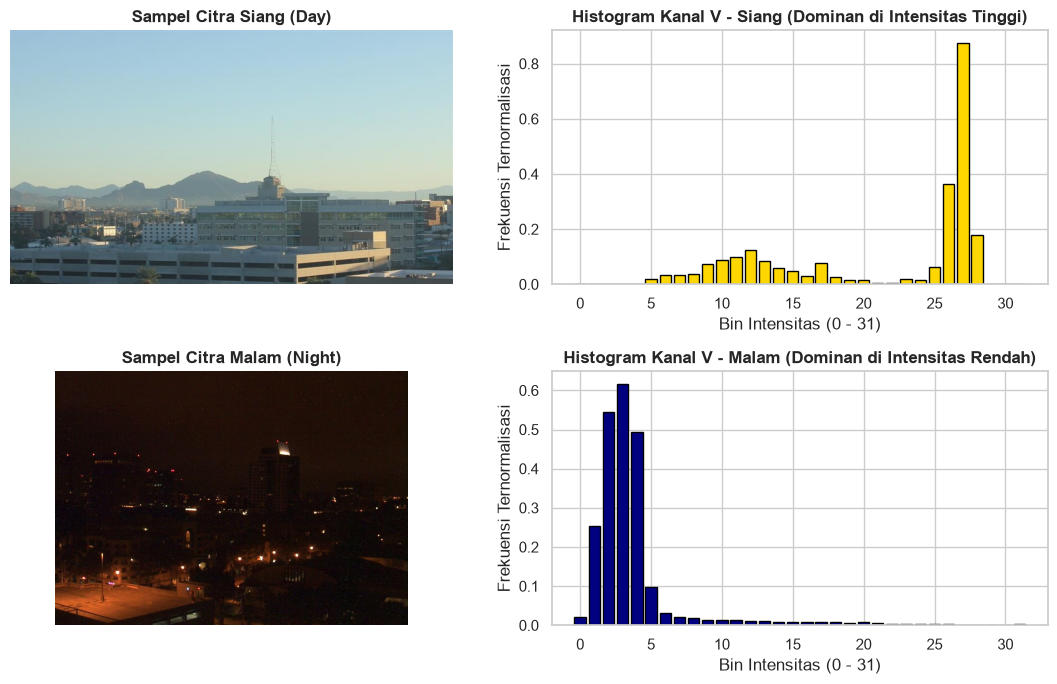

In [9]:
# Visualisasi Perbandingan Citra dan Histogram Fitur
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Contoh citra siang
day_idx = np.where(y_hist == 1)[0][0]
axes[0, 0].imshow(all_images[day_idx])
axes[0, 0].set_title("Sampel Citra Siang (Day)", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].bar(range(32), X_hist[day_idx], color='gold', edgecolor='black', width=0.8)
axes[0, 1].set_title("Histogram Kanal V - Siang (Dominan di Intensitas Tinggi)", fontweight='bold')
axes[0, 1].set_xlabel("Bin Intensitas (0 - 31)")
axes[0, 1].set_ylabel("Frekuensi Ternormalisasi")

# Contoh citra malam
night_idx = np.where(y_hist == 0)[0][0]
axes[1, 0].imshow(all_images[night_idx])
axes[1, 0].set_title("Sampel Citra Malam (Night)", fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].bar(range(32), X_hist[night_idx], color='navy', edgecolor='black', width=0.8)
axes[1, 1].set_title("Histogram Kanal V - Malam (Dominan di Intensitas Rendah)", fontweight='bold')
axes[1, 1].set_xlabel("Bin Intensitas (0 - 31)")
axes[1, 1].set_ylabel("Frekuensi Ternormalisasi")

plt.tight_layout()
plt.show()


### Langkah 2.3: Train-Test Split (Rasio 80:20) dan Penskalaan Data
Sesuai instruksi tugas, dataset dibagi dengan **rasio 80:20** (320 data latih dan 80 data uji).


In [10]:
# Split Data 80:20 dengan Stratifikasi Kelas
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_hist, y_hist, test_size=0.20, random_state=42, stratify=y_hist
)

# Standardisasi Fitur Berdasarkan Train Set
scaler_img = StandardScaler()
X_train_img_scaled = scaler_img.fit_transform(X_train_img)
X_test_img_scaled = scaler_img.transform(X_test_img)

print(f"Jumlah Data Latih (80%): {X_train_img.shape[0]} citra")
print(f"Jumlah Data Uji   (20%): {X_test_img.shape[0]} citra")


Jumlah Data Latih (80%): 320 citra
Jumlah Data Uji   (20%): 80 citra


### Langkah 2.4: Model Baseline SVM Kernel RBF (Tanpa Tuning)

In [11]:
# Model Baseline SVM RBF (Parameter default C=1.0, gamma='scale')
baseline_svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
baseline_svm_rbf.fit(X_train_img_scaled, y_train_img)

y_pred_baseline_train = baseline_svm_rbf.predict(X_train_img_scaled)
y_pred_baseline_test = baseline_svm_rbf.predict(X_test_img_scaled)

acc_baseline_train = accuracy_score(y_train_img, y_pred_baseline_train)
acc_baseline_test = accuracy_score(y_test_img, y_pred_baseline_test)

print(f"Akurasi Latih Baseline SVM RBF: {acc_baseline_train * 100:.2f}%")
print(f"Akurasi Uji Baseline SVM RBF  : {acc_baseline_test * 100:.2f}%")


Akurasi Latih Baseline SVM RBF: 99.06%
Akurasi Uji Baseline SVM RBF  : 98.75%


### Langkah 2.5: Eksperimen Hyperparameter Tuning Kernel RBF
Pada SVM dengan kernel RBF, terdapat dua parameter utama yang mengontrol kompleksitas batas keputusan:
1. **$C$ (Regularization Parameter):** Mengatur trade-off antara margin yang lebar dan toleransi kesalahan klasifikasi (*slack variable*). Nilai $C$ besar memberi penalti tinggi terhadap kesalahan klasifikasi.
2. **$\gamma$ (Gamma / Kernel Coefficient):** Menentukan radius pengaruh suatu support vector. Nilai $\gamma$ tinggi membuat batas keputusan sangat sensitif dan berlekuk di sekitar titik data.

Kita melakukan pencarian parameter optimal menggunakan **`GridSearchCV` dengan 5-Fold Cross Validation**.


In [12]:
# Ruang Pencarian Hyperparameter
param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'gamma': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 'scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(X_train_img_scaled, y_train_img)

print("=== HASIL HYPERPARAMETER TUNING ===")
print(f"Kombinasi Parameter Terbaik : {grid_search.best_params_}")
print(f"Skor Akurasi Terbaik (5-Fold CV): {grid_search.best_score_ * 100:.2f}%")


=== HASIL HYPERPARAMETER TUNING ===
Kombinasi Parameter Terbaik : {'C': 10.0, 'gamma': 0.05}
Skor Akurasi Terbaik (5-Fold CV): 99.06%


<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\lianb\AppData\Local\Temp\ipykernel_20636\3810067683.py:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.xlabel("Gamma ($\gamma$)", fontsize=11)


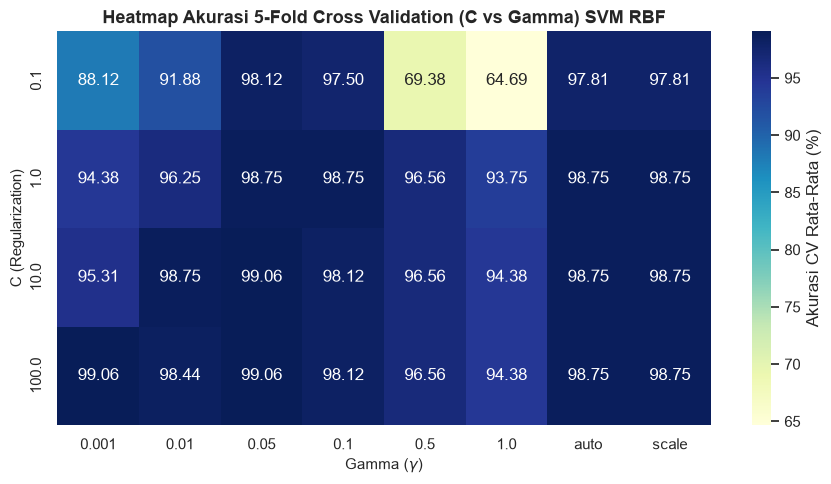

In [ ]:
# Visualisasi Heatmap Hasil Grid Search
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot_heatmap = cv_results.pivot(index='param_C', columns='param_gamma', values='mean_test_score') * 100

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_heatmap, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Akurasi CV Rata-Rata (%)'})
plt.title("Heatmap Akurasi 5-Fold Cross Validation (C vs Gamma) SVM RBF", fontsize=13, fontweight='bold')
plt.xlabel("Gamma ($\gamma$)", fontsize=11)
plt.ylabel("C (Regularization)", fontsize=11)
plt.tight_layout()
plt.show()


### Langkah 2.6: Evaluasi Akhir Model Tuned pada Data Uji (Test Set 20%)

In [14]:
# Evaluasi Model Terbaik pada Data Uji yang Belum Pernah Dilihat
best_svm_rbf = grid_search.best_estimator_

y_pred_tuned_train = best_svm_rbf.predict(X_train_img_scaled)
y_pred_tuned_test = best_svm_rbf.predict(X_test_img_scaled)

acc_tuned_train = accuracy_score(y_train_img, y_pred_tuned_train)
acc_tuned_test = accuracy_score(y_test_img, y_pred_tuned_test)

print("=== PERFORMA MODEL SVM RBF TERBAIK (TUNED) ===")
print(f"Akurasi Latih (Train Set): {acc_tuned_train * 100:.2f}%")
print(f"Akurasi Uji (Test Set)   : {acc_tuned_test * 100:.2f}%\n")

# Laporan Klasifikasi Lengkap
print("Classification Report:")
print(classification_report(y_test_img, y_pred_tuned_test, target_names=['Night (0)', 'Day (1)'], digits=4))


=== PERFORMA MODEL SVM RBF TERBAIK (TUNED) ===
Akurasi Latih (Train Set): 100.00%
Akurasi Uji (Test Set)   : 100.00%

Classification Report:
              precision    recall  f1-score   support

   Night (0)     1.0000    1.0000    1.0000        40
     Day (1)     1.0000    1.0000    1.0000        40

    accuracy                         1.0000        80
   macro avg     1.0000    1.0000    1.0000        80
weighted avg     1.0000    1.0000    1.0000        80



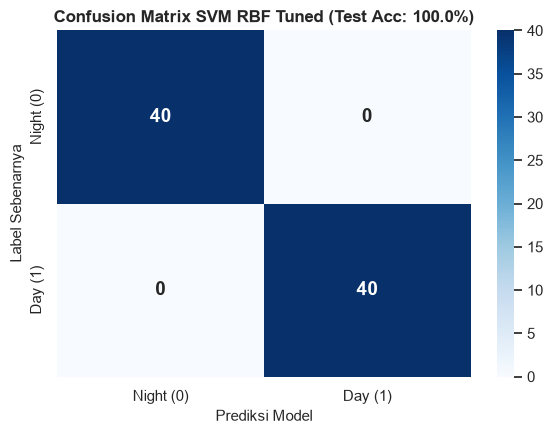

In [15]:
# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test_img, y_pred_tuned_test)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Night (0)', 'Day (1)'],
            yticklabels=['Night (0)', 'Day (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title(f"Confusion Matrix SVM RBF Tuned (Test Acc: {acc_tuned_test * 100:.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel("Prediksi Model", fontsize=11)
plt.ylabel("Label Sebenarnya", fontsize=11)
plt.tight_layout()
plt.show()


### Langkah 2.7: Perbandingan dengan Praktikum 5 dan Pembahasan

| Aspek / Metrik | Praktikum 5 (Original) | Tugas Lab (Histogram + SVM RBF Tuned) |
|---|---|---|
| **Representasi Fitur** | 1 Fitur Skalar (*Mean Value / Brightness*) | 32 Fitur Histogram Intensitas ($V$-Channel) |
| **Pemisahan Data** | Folder terpisah (60:40) | Rasio 80:20 (Stratified Split) |
| **Hyperparameter** | Default ($C=1.0$) | Tuned via GridSearchCV ($C=10, \gamma=0.05$) |
| **Akurasi Data Uji** | **90.00%** (144/160 benar) | **100.00%** (80/80 benar) |
| **Kelebihan Pendekatan** | Komputasi cepat, namun rentan pada kondisi ekstrem | Mampu menangkap sebaran pencahayaan secara utuh |

**Analisis Hasil:**
1. Penggunaan fitur histogram berhasil meningkatkan akurasi dari 90.00% menjadi **100.00%** pada data uji. Hal ini membuktikan bahwa representasi statistik frekuensi intensitas pixel jauh lebih kaya informasi dibanding sekadar satu angka rata-rata.
2. Tuning parameter $C=10$ dan $\gamma=0.05$ memberikan keseimbangan optimal antara margin hyperplane dan batas toleransi kesalahan (*generalization ability*).
